In [2]:
# %% load environment
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader

join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F

from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics

from monai.metrics import DiceMetric


from utils.utils_mammo_automatic import (
    MedSAMMammoDataset,
    ComposeSampleTransforms,
    EnsureImageChannels,
    ResizeSample,
    BBoxFromMask,
    medsam_inference_single,
    medsam_inference_batch,

)



## OOD detection

In [3]:
root="/home/jovyan/thesis_project"

device = "cuda:1"
ckpt = root + "/MedSAM/work_dir/MedSAM/medsam_vit_b.pth"  
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

In [4]:
def mammo_collate_fn(batch):
    """
    Custom collate for MedSAMMammoDataset.

    Stacks:
        - image: Tensor[B, C, H, W]
        - mask: Tensor[B, 1, H, W] if all masks are tensors
        - label: Tensor[B]

    Keeps as lists:
        - bbox: list[Tensor[N_i, 4] | None]
        - path: list[str]
        - annotation_path: list[str | None]
        - metadata: list[dict] (if present)
    """
    out = {}

    # Always stack images
    out["image"] = torch.stack([sample["image"] for sample in batch], dim=0)

    # Labels
    if "label" in batch[0]:
        out["label"] = torch.stack([sample["label"] for sample in batch], dim=0)

    # Masks: stack only if all are tensors
    if "mask" in batch[0]:
        masks = [sample.get("mask", None) for sample in batch]
        if all(m is not None for m in masks):
            out["mask"] = torch.stack(masks, dim=0)
        else:
            out["mask"] = masks

    # BBoxes: keep as list because shapes vary [N_i, 4]
    if "bbox" in batch[0]:
        out["bbox"] = [sample.get("bbox", None) for sample in batch]

    # Paths
    if "path" in batch[0]:
        out["path"] = [sample.get("path", None) for sample in batch]

    if "annotation_path" in batch[0]:
        out["annotation_path"] = [sample.get("annotation_path", None) for sample in batch]

    # Metadata
    if "metadata" in batch[0]:
        out["metadata"] = [sample.get("metadata", None) for sample in batch]

    return out

### Loading both ID and OOD datasets with different DataLoaders

In [5]:
dataset_path = Path(root + "/datasets/INbreast/INbreast Release 1.0/")

id_dicom_dir = dataset_path / "MassDICOMs"
id_xml_dir = dataset_path / "MassXML/"

ood_dicom_dir = dataset_path / "NoMassDICOMs"
ood_xml_dir = dataset_path / "NoMassXML/"


def select_files(files_dir):
    selected_files = []
    selected_files.extend(sorted(files_dir.rglob("*.dcm")))
    return selected_files



medsam_model_transform_id = ComposeSampleTransforms([
    BBoxFromMask(roi_class_name="Mass"),
    EnsureImageChannels(3),
    ResizeSample((1024, 1024)),
])

medsam_model_transform_ood = ComposeSampleTransforms([
    BBoxFromMask(roi_class_name=None),
    EnsureImageChannels(3),
    ResizeSample((1024, 1024)),
])


id_dataset= MedSAMMammoDataset(file_paths= select_files(id_dicom_dir),
                           annotation_dir_name= "MassXML",
                           skip_empty_mask=True,
                           transform=medsam_model_transform_id)



ood_dataset= MedSAMMammoDataset(file_paths= select_files(ood_dicom_dir),     #this won't find any masks and thus no bboxes
                           annotation_dir_name= "NoMassXML",
                           label=-1,
                           skip_empty_mask=False,
                           transform=medsam_model_transform_ood)


id_loader= DataLoader(id_dataset, batch_size=4, shuffle=False, num_workers=0)
ood_loader= DataLoader(ood_dataset, batch_size=4, shuffle=False, num_workers=0, collate_fn=mammo_collate_fn)

found 108 samples
found 302 samples


In [7]:
ood_dataset[0].keys()

annotation_path:None
annot_path is none!


dict_keys(['image', 'label', 'path', 'annotation_path', 'mask', 'bbox', 'original_size', 'resized_size'])

annotation_path:None
annot_path is none!
annotation_path:/home/jovyan/thesis_project/datasets/INbreast/INbreast Release 1.0/NoMassXML/22678953.xml
suffix:.xml
annotation_path:None
annot_path is none!
annotation_path:None
annot_path is none!


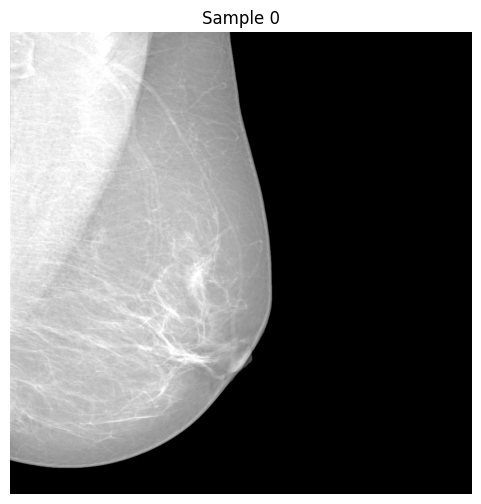

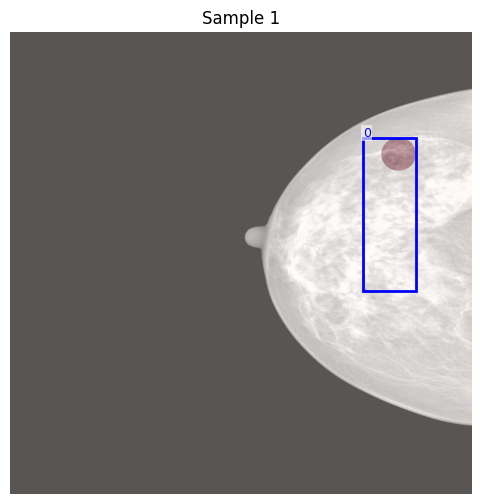

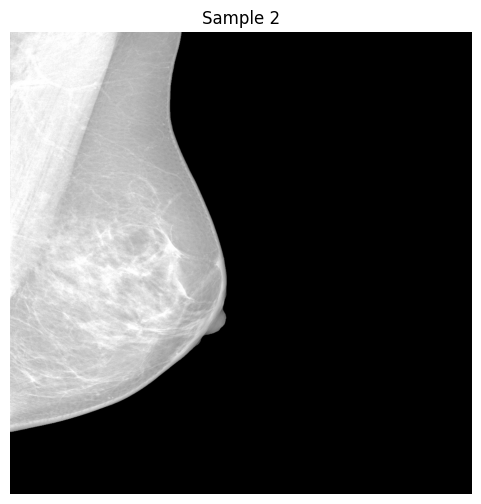

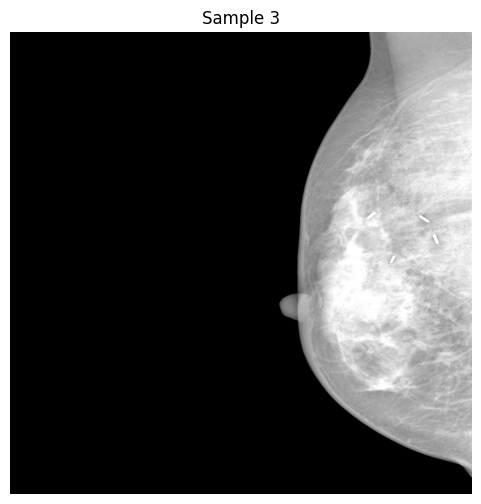

In [9]:
def show_batch(batch, n=4, mask_alpha=0.35, bbox_color="blue"):
    images = batch["image"]
    masks = batch.get("mask", None)
    bboxes = batch.get("bbox", None)

    batch_size = images.shape[0]

    for i in range(min(n, batch_size)):
        img = images[i].detach().cpu()

        # [C, H, W] -> [H, W, C]
        img = img.permute(1, 2, 0).numpy()

        # Handle grayscale vs RGB display
        if img.shape[-1] == 1:
            display_img = img.squeeze(-1)
            is_gray = True
        elif img.shape[-1] == 3:
            # If 3 channels are repeated grayscale, display as grayscale
            if np.allclose(img[..., 0], img[..., 1]) and np.allclose(img[..., 1], img[..., 2]):
                display_img = img[..., 0]
                is_gray = True
            else:
                display_img = img
                is_gray = False
        else:
            raise ValueError(f"Unexpected image shape for visualization: {img.shape}")

        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

        if is_gray:
            ax.imshow(display_img, cmap="gray")
        else:
            ax.imshow(display_img)

        # Overlay mask if present
        if masks is not None:
            mask_i = masks[i]
            if mask_i is not None:
                if isinstance(mask_i, torch.Tensor):
                    mask_i = mask_i.detach().cpu().numpy()
                mask_i = np.asarray(mask_i)

                # expected [1, H, W] -> [H, W]
                if mask_i.ndim == 3 and mask_i.shape[0] == 1:
                    mask_i = mask_i[0]
                elif mask_i.ndim != 2:
                    raise ValueError(f"Unexpected mask shape for visualization: {mask_i.shape}")

                ax.imshow(mask_i, alpha=mask_alpha, cmap="Reds")

        # Draw bbox / bboxes if present
        if bboxes is not None:
            bbox_i = bboxes[i]

            if bbox_i is not None:
                if isinstance(bbox_i, torch.Tensor):
                    bbox_i = bbox_i.detach().cpu().numpy()
                bbox_i = np.asarray(bbox_i)

                # Normalize to [N, 4]
                if bbox_i.ndim == 1 and bbox_i.shape[0] == 4:
                    bbox_i = bbox_i[None, :]
                elif bbox_i.ndim == 2 and bbox_i.shape[1] == 4:
                    pass
                else:
                    raise ValueError(f"Unexpected bbox shape for visualization: {bbox_i.shape}")

                for j, (x0, y0, x1, y1) in enumerate(bbox_i):
                    rect = plt.Rectangle(
                        (x0, y0),
                        x1 - x0,
                        y1 - y0,
                        edgecolor=bbox_color,
                        facecolor="none",
                        linewidth=2,
                    )
                    ax.add_patch(rect)

                    # Optional label per box
                    ax.text(
                        x0,
                        max(0, y0 - 3),
                        f"{j}",
                        color=bbox_color,
                        fontsize=9,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
                    )

        ax.set_title(f"Sample {i}")
        ax.axis("off")
        plt.show()
        
batch=next(iter(ood_loader))
show_batch(batch)

In [23]:
# Stage 1: Create DNN
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

# Pass ID data through encoder and fit Mahalanobis distance metric
feats_list_id = []
labels_list_id = []

model.eval()

with torch.no_grad():
    for batch in id_loader:
        imgs = batch["image"].to(device)
        y = batch["label"].to(device)

        z = model.image_encoder(imgs)              # [B, C, H, W] feature maps
        z = z.mean(dim=(2, 3))                     # [B, C] global average pool

        feats_list_id.append(z)
        labels_list_id.append(y)

Z_id = torch.cat(feats_list_id, dim=0)
Y_id = torch.cat(labels_list_id, dim=0)

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)

No device given. Will use 'cuda:1'.


In [24]:
# Predict on OOD dataset
feats_list = []

with torch.no_grad():
    for batch in ood_loader:
        imgs = batch["image"].to(device)
        z = model.image_encoder(imgs)
        z = z.mean(dim=(2, 3))
        feats_list.append(z)

Z_ood = torch.cat(feats_list, dim=0)


scores_id = detector.predict_features(Z_id)
scores_ood = detector.predict_features(Z_ood)

In [25]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(scores_id), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([scores_id.detach().cpu(), scores_ood.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 1.0, 'AUTC': 0.4010177254676819, 'AUPR-IN': 1.0, 'AUPR-OUT': 1.0, 'FPR95TPR': 0.0}


## Proceed to segmentation with only ID data

In [6]:
batch_dice_scores=[]

dice_metric = DiceMetric(
    include_background=False,   # usually better for medical tasks
    reduction="mean"
)

with torch.no_grad():
    for batch in data_loader:
        
        images = batch["image"].to(device)   # [B, 3, 1024, 1024]
        boxes = batch["bbox"].to(device)     # [B, 4]
        masks=batch["mask"].to(device)       # [B, 3, 1024, 1024]
    
        img_embed = model.image_encoder(images)   # [B, 256, 64, 64]

        pred_mask = medsam_inference_batch(
            medsam_model=model,
            img_embed=img_embed,
            box_1024=boxes,
            H=images.shape[-2],
            W=images.shape[-1],
        )

        dice = dice_metric(
            y_pred=pred_mask,   # [B, 1, H, W]
            y=masks             # [B, 1, H, W]
            )
        
        batch_dice_scores.append(dice.mean().item())

print(batch_dice_scores)

[0.8468047976493835, 0.9190992116928101, 0.7695392966270447, 0.7449349761009216, 0.7360984086990356, 0.8980722427368164, 0.8406465649604797, 0.721393346786499, 0.8753263354301453, 0.8247726559638977, 0.860431432723999, 0.9020434617996216, 0.741344153881073, 0.6563059091567993, 0.8705580830574036, 0.8715458512306213, 0.8290415406227112, 0.8648003339767456, 0.7338440418243408, 0.910068154335022, 0.8758938312530518, 0.5571274757385254, 0.8143503665924072, 0.8659083843231201, 0.7918447256088257, 0.8809022903442383, 0.8491790294647217]


In [7]:
print(sum(batch_dice_scores)/len(batch_dice_scores))

0.8167361815770467
